In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv('https://github.com/sukhioo7/dataset/blob/main/002%203.01.Country-clusters.csv?raw=True')

In [3]:
data

,Country,Latitude,Longitude,Language
0,USA,44.97,-103.77,English
1,Canada,62.40,-96.80,English
2,France,46.75,2.40,French
3,UK,54.01,-2.53,English
4,Germany,51.15,10.40,German
5,Australia,-25.45,133.11,English


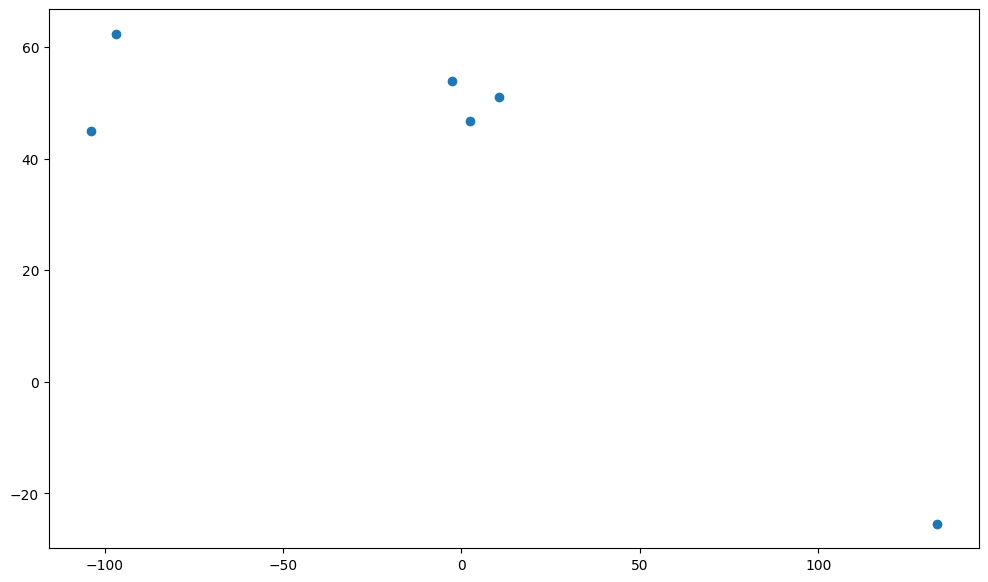

In [4]:
plt.figure(figsize=(12,7))
plt.scatter(x=data['Longitude'],y=data['Latitude'])
plt.show()

In [8]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3)

In [9]:
kmeans.fit(data[['Longitude','Latitude']])

KMeans(n_clusters=3)

In [10]:
data['Cluster'] = kmeans.predict(data[['Longitude','Latitude']])

In [11]:
data

,Country,Latitude,Longitude,Language,Cluster
0,USA,44.97,-103.77,English,1
1,Canada,62.40,-96.80,English,1
2,France,46.75,2.40,French,0
3,UK,54.01,-2.53,English,0
4,Germany,51.15,10.40,German,0
5,Australia,-25.45,133.11,English,2


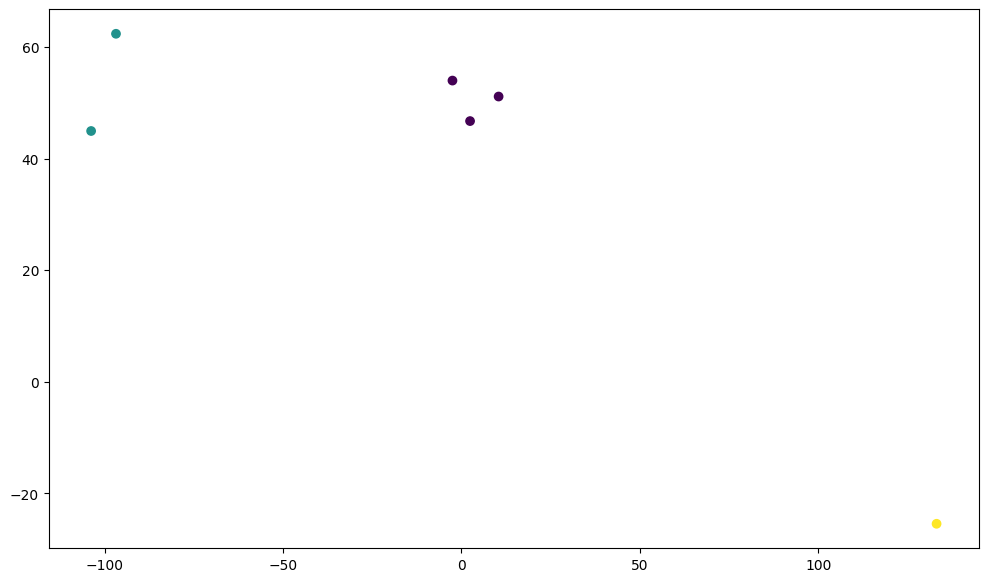

In [13]:
plt.figure(figsize=(12,7))
plt.scatter(x=data['Longitude'],y=data['Latitude'],c = data['Cluster'])
plt.show()

In [14]:
data['Language-Number'] = data['Language'].map({'English':1,'French':2,'German':3})

In [15]:
data

,Country,Latitude,Longitude,Language,Cluster,Language-Number
0,USA,44.97,-103.77,English,1,1
1,Canada,62.40,-96.80,English,1,1
2,France,46.75,2.40,French,0,2
3,UK,54.01,-2.53,English,0,1
4,Germany,51.15,10.40,German,0,3
5,Australia,-25.45,133.11,English,2,1


In [16]:
kmeans = KMeans(n_clusters=2)

In [17]:
kmeans.fit(data[['Language-Number']])

KMeans(n_clusters=2)

In [18]:
data['Lang-Clusters']  = kmeans.predict(data[['Language-Number']])

In [19]:
data

,Country,Latitude,Longitude,Language,Cluster,Language-Number,Lang-Clusters
0,USA,44.97,-103.77,English,1,1,0
1,Canada,62.40,-96.80,English,1,1,0
2,France,46.75,2.40,French,0,2,0
3,UK,54.01,-2.53,English,0,1,0
4,Germany,51.15,10.40,German,0,3,1
5,Australia,-25.45,133.11,English,2,1,0


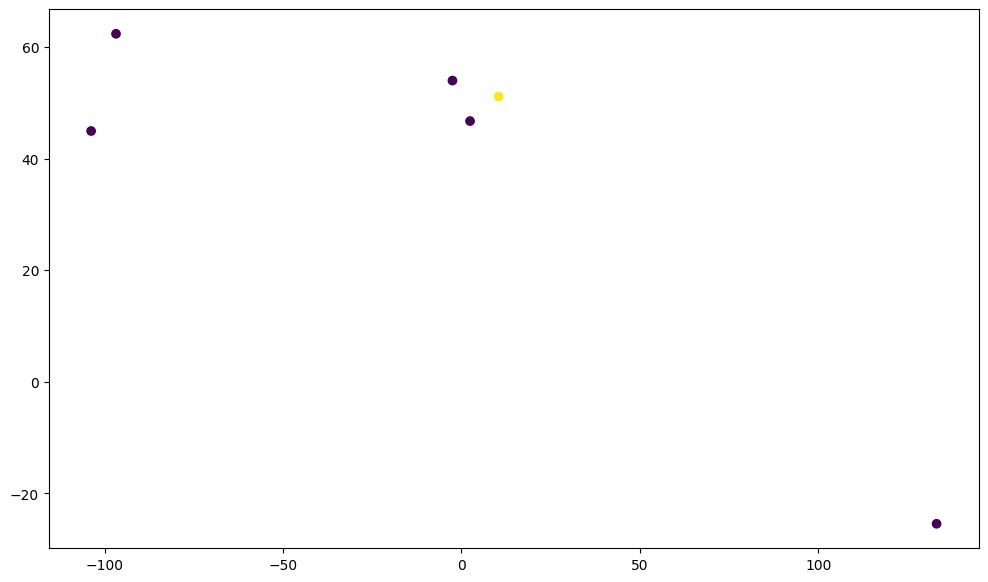

In [20]:
plt.figure(figsize=(12,7))
plt.scatter(x=data['Longitude'],y=data['Latitude'],c = data['Lang-Clusters'])
plt.show()

In [21]:
customers = pd.read_csv('https://raw.githubusercontent.com/sukhioo7/dataset/refs/heads/main/011%203.12.Example.csv')

In [22]:
customers.head()

,Satisfaction,Loyalty
0,4,-1.33
1,6,-0.28
2,5,-0.99
3,7,-0.29
4,4,1.06


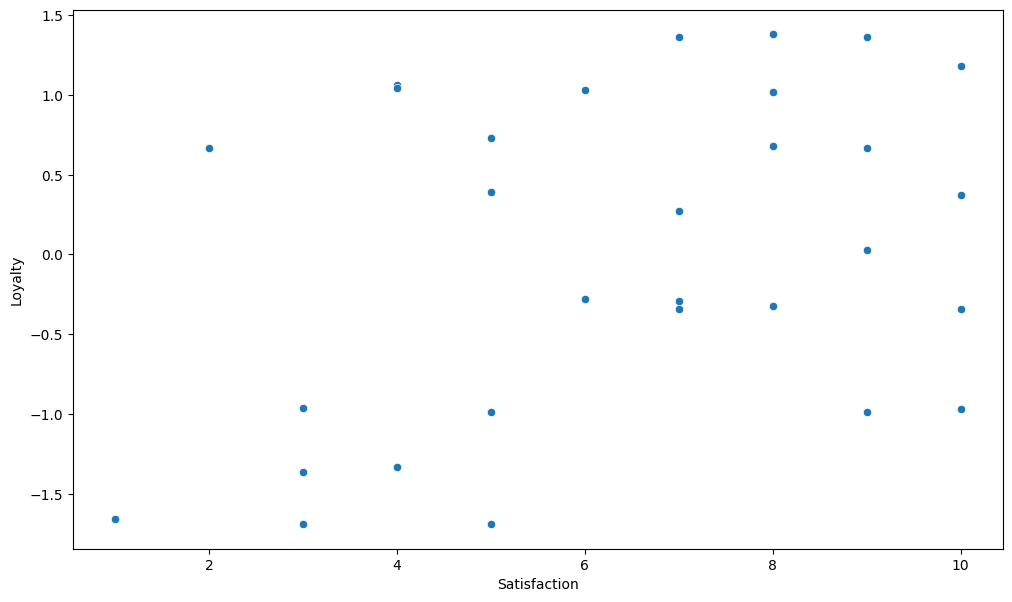

In [23]:
plt.figure(figsize=(12,7))
sns.scatterplot(data=customers,x='Satisfaction',y='Loyalty')
plt.show()

In [24]:
kmeans = KMeans(n_clusters=2)

In [25]:
kmeans.fit(customers[['Satisfaction','Loyalty']])

KMeans(n_clusters=2)

In [26]:
customers['Clusters'] = kmeans.predict(customers[['Satisfaction','Loyalty']])

In [27]:
customers.head()

,Satisfaction,Loyalty,Clusters
0,4,-1.33,1
1,6,-0.28,1
2,5,-0.99,1
3,7,-0.29,0
4,4,1.06,1


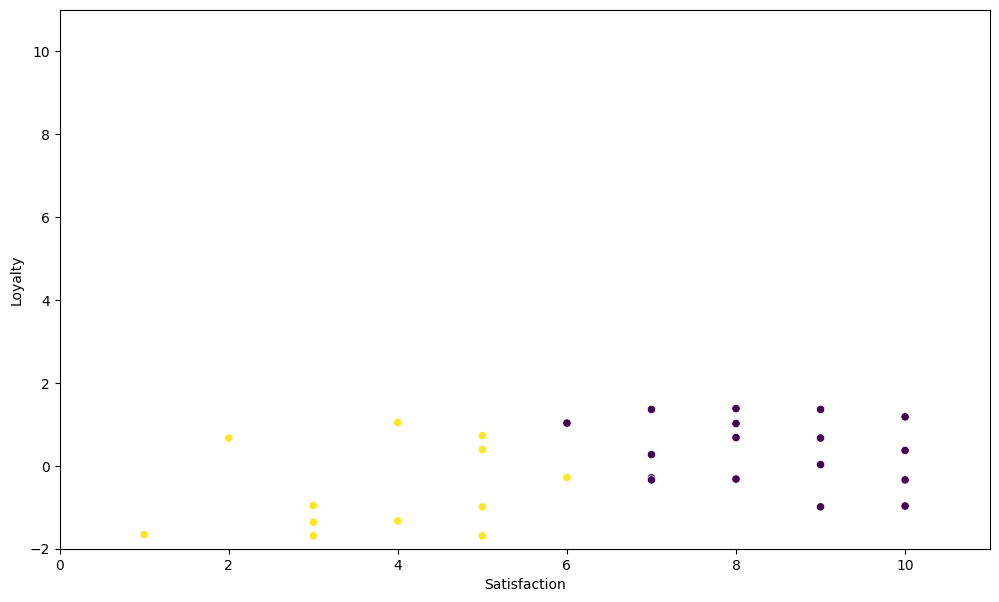

In [28]:
plt.figure(figsize=(12,7))
sns.scatterplot(data=customers,x='Satisfaction',y='Loyalty',c=customers['Clusters'])
plt.xlim((0,11))
plt.ylim((-2,11))
plt.show()

In [29]:
from sklearn.preprocessing import StandardScaler
standard_scaler = StandardScaler()

In [30]:
standard_scaler.fit(customers[['Satisfaction','Loyalty']])

StandardScaler()

In [31]:
scaled_data = standard_scaler.transform(customers[['Satisfaction','Loyalty']])

In [32]:
kmeans.fit(scaled_data)

KMeans(n_clusters=2)

In [33]:
customers['Clusters'] = kmeans.predict(scaled_data)

In [34]:
customers.head()

,Satisfaction,Loyalty,Clusters
0,4,-1.33,1
1,6,-0.28,1
2,5,-0.99,1
3,7,-0.29,0
4,4,1.06,1


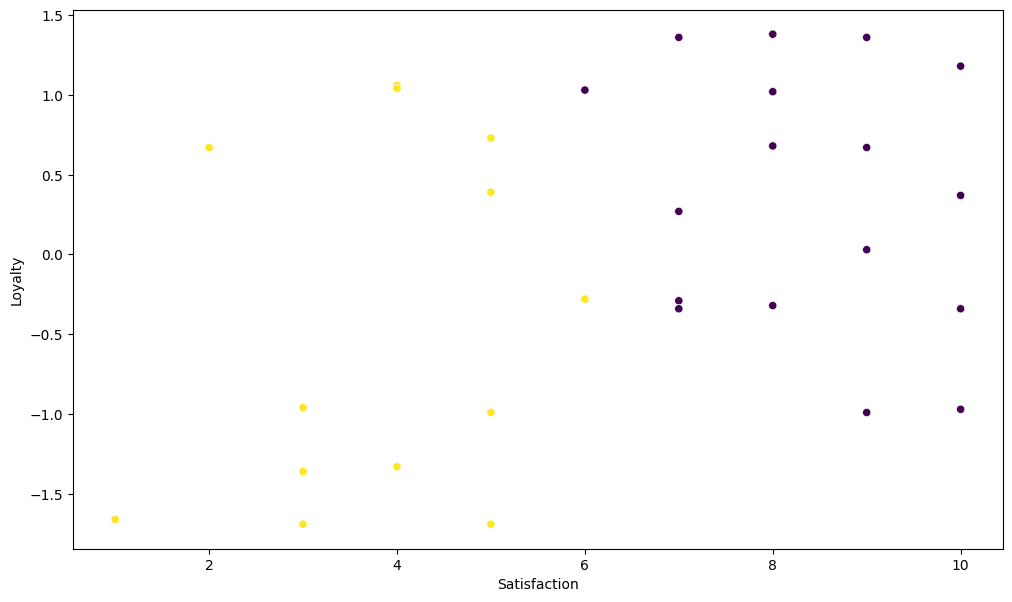

In [35]:
plt.figure(figsize=(12,7))
sns.scatterplot(data=customers,x='Satisfaction',y='Loyalty',c=customers['Clusters'])
plt.show()

In [36]:
wcss =[]
for k in range(2,10):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

In [37]:
wcss

[32.43692292542639,
 22.956419533106974,
 10.247181805928422,
 7.858104421785561,
 6.8431019522222325,
 6.752702787915366,
 5.442159358439798,
 4.300589516663438]

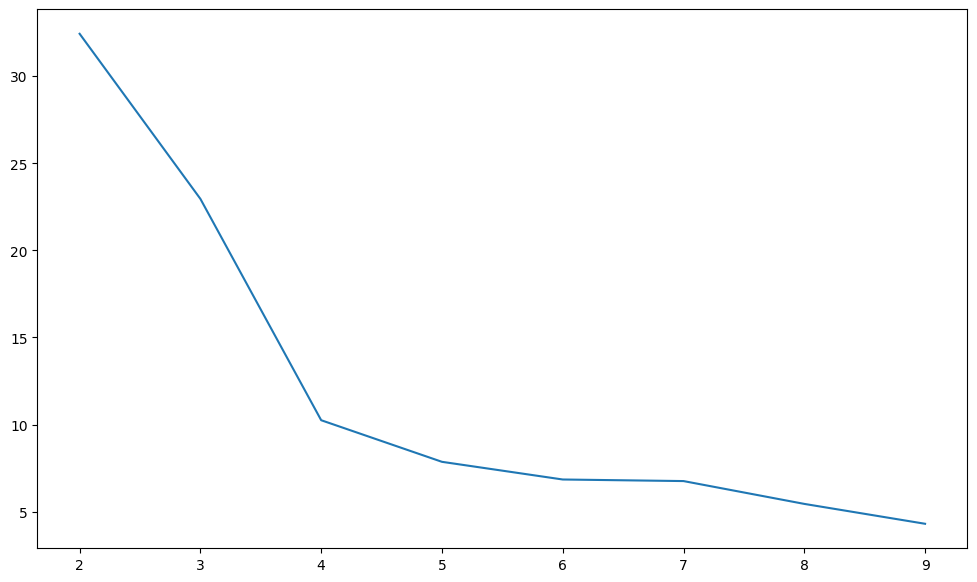

In [38]:
plt.figure(figsize=(12,7))
sns.lineplot(x=range(2,10),y=wcss)
plt.show()